In [1]:
%cd ../../

/Users/hoangle/Projects/untangling-people/ylva/fwo_models


In [2]:
import matplotlib.pyplot as plt

import pandas as pd
import polars as pl
import numpy as np
import holidays
from darts import TimeSeries
from darts.metrics import rmse, mape
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from darts.models import XGBModel, LightGBMModel, CatBoostModel, ARIMA, RandomForest
from darts.dataprocessing.transformers import Scaler, BoxCox, Diff
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data

In [4]:
EPS = 1e-6
DATE_MIN = pl.lit('2023-01-09').str.to_date()
DATE_MAX = pl.lit('2024-10-31').str.to_date()
CUTOFF_DATE = pd.to_datetime("2024-09-01")

In [5]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)
pos.head()


column_1,column_2,column_3,column_4,column_5,column_6,column_7
str,str,str,str,str,i64,str
"""2.1.2023""","""10:31""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:35""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:36""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",2,"""1,8"""


<Axes: xlabel='date'>

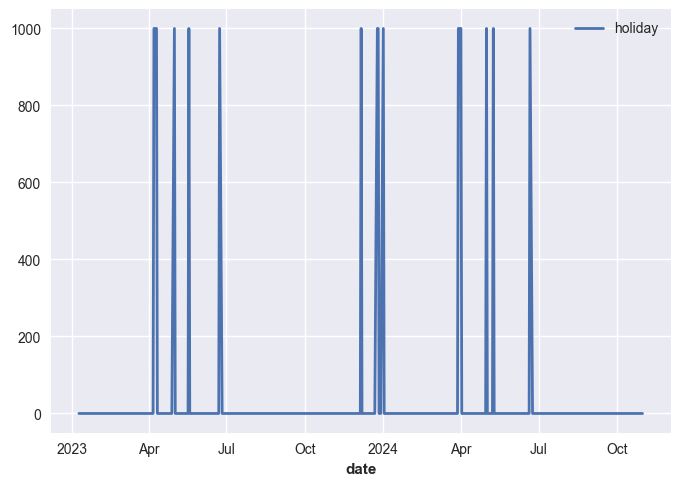

In [6]:
fin_holidays = holidays.Finland(years=[2023, 2024, 2025])
dim_holiday = pl.from_records([
    {'date': d, 'name_holiday': n}
    for d, n in fin_holidays.items()
])

cov_holiday = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(DATE_MIN, DATE_MAX, '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_holiday, on='date', how='left')
    .with_columns(pl.col('name_holiday').is_not_null().cast(pl.Int32).alias('holiday'))
    .drop('name_holiday')


    # Cast to categorical type
    .with_columns(
        pl
        .col('holiday') * 1000
        # .cast(pl.String())
        # .cast(pl.Categorical())
    )

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)

# cov_holiday.head()

series_holiday = (
    TimeSeries
    .from_dataframe(
        df=cov_holiday.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols='holiday'
    )
    # .astype(np.float32)
)
series_holiday.plot()


In [7]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)



# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)



# Accum by restaurant and date
pos = (
    pos
    .with_columns(
        pl.col('datetime').dt.date().alias('date')
    )

    .group_by('restaurant', 'date')
    .agg(pl.col('pcs').sum())
)


# Trim records out of the range

pos = (
    pos.filter(pl.col('date') >= DATE_MIN)

    # make it possible for MAPE and log
    .with_columns((pl.col('pcs') + EPS))
)

pos_final = (
    pos
    .pivot(on='restaurant', index='date', values='pcs')
    .sort('date')
)

series = (
    TimeSeries
    .from_dataframe(
        pos_final.to_pandas(),
        time_col='date',
        value_cols=[
            'che',
            # 'exa',
            # 'phy',
            # 'vik'
        ],
        fillna_value=EPS,
        freq='B',
    )
    # .astype(np.float32)
)


# Explore

<Axes: title={'center': 'pos'}, xlabel='date'>

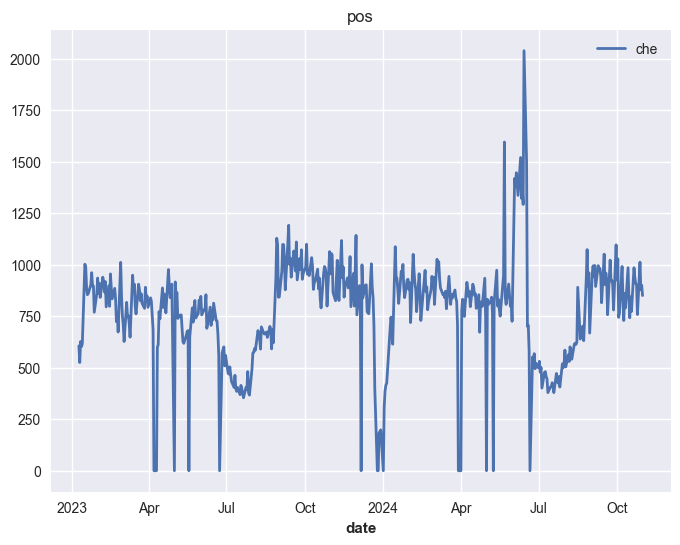

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# series_holiday.plot(ax=ax, title="holiday")
series.plot(ax=ax, title='pos')

In [9]:
df = series.to_dataframe()
df.head()

component,che
date,
2023-01-09,606.000001
2023-01-10,525.000001
2023-01-11,627.000001
2023-01-12,602.000001
2023-01-13,616.000001


In [10]:
mstl = MSTL(df["vik"], periods=[10])
res = mstl.fit()
ax = res.plot()

KeyError: 'vik'

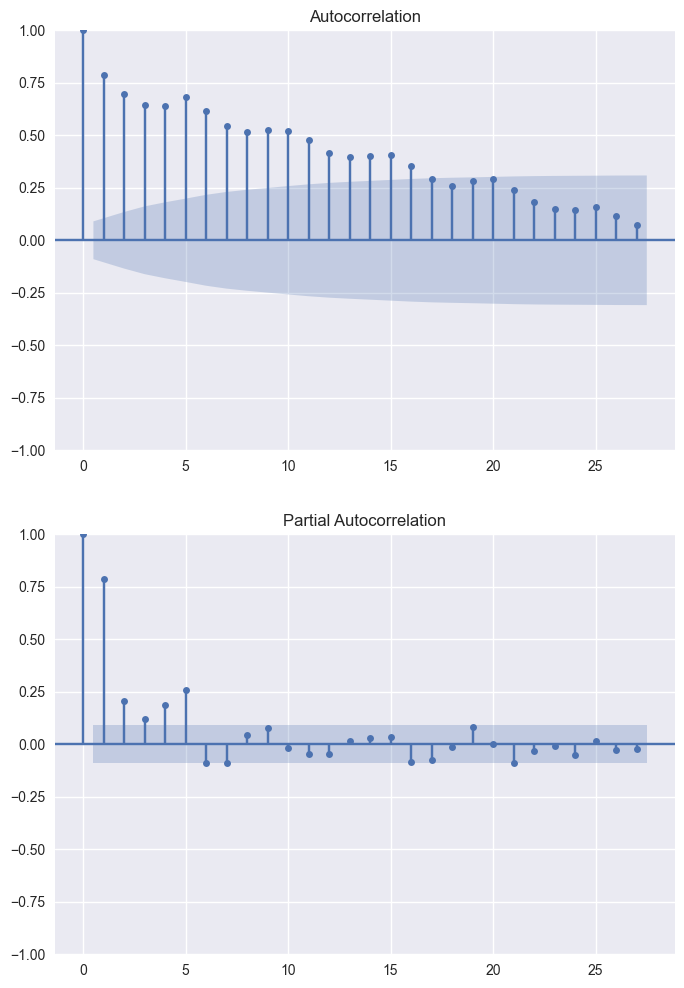

In [ ]:
fig = plt.figure(figsize=(8, 12))

ax = fig.add_subplot(211)
_ = plot_acf(df['vik'], ax=ax)

ax = fig.add_subplot(212)
_ = plot_pacf(df['vik'], ax=ax)

Text(0.5, 1.0, 'mape = 67.1813')

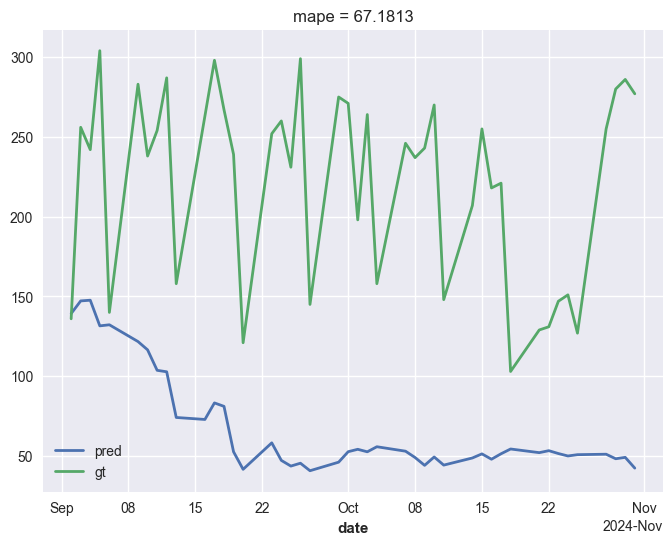

In [12]:
series_train, series_test = series.split_before(CUTOFF_DATE)

# transformer_target = Scaler(MinMaxScaler(feature_range=(-1, 1)))
# series_train_transformed = transformer_target.fit_transform(series_train)
# series_val_transformed = transformer_target.transform(series_test)

# transformer_target = BoxCox(lmbda=1)
# series_train_transformed = transformer_target.fit_transform(series_train)

# diff = Diff(lags=1, dropna=True)
# series_transformed = diff.fit_transform(series)
# series_train_diff, series_val_diff = series_transformed.split_before(CUTOFF_DATE)



add_encoders={
    'cyclic': {'future': ['month', 'dayofweek', 'day']},
    'datetime_attribute': {'future': ['month', 'dayofweek', 'day', 'year']},
}
# model = ARIMA(p=10, d=0, q=3, add_encoders=add_encoders)
model = XGBModel(lags=15, output_chunk_length=1)
model.fit(series_train)
preds = model.predict(len(series_test))

# preds = diff.inverse_transform(series_train_diff.concatenate(preds)).drop_before(CUTOFF_DATE)
# preds = transformer_target.inverse_transform(preds)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

preds.plot(ax=ax, label='pred')
series_test.plot(ax=ax, label='gt')
ax.set_title(f"mape = {mape(series_test, preds):.4f}")
